In [18]:
!pip install geemap earthengine-api -q

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [19]:
import ee
import geemap
import pandas as pd

ee.Authenticate()
ee.Initialize(project='ee-pakjira')

In [20]:
# Load FAO GAUL (Administrative boundaries)
admin = ee.FeatureCollection("FAO/GAUL/2015/level1")

# Select Ang Thong Province
roi = admin.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Thailand'),
        ee.Filter.eq('ADM1_NAME', 'Ang Thong')
    )
)

# Sentinel-2 composite
image = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
         .filterBounds(roi)
         .filterDate('2024-01-01','2024-12-31')
         .median()
         .clip(roi))

# Indices
ndvi = image.normalizedDifference(['B8','B4']).rename('NDVI')
ndwi = image.normalizedDifference(['B3','B8']).rename('NDWI')
ndbi = image.normalizedDifference(['B11','B8']).rename('NDBI')

# Features
features = image.select(['B2','B3','B4','B8']).addBands([ndvi,ndwi,ndbi])

# Dynamic World labels
dw = (ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
      .filterBounds(roi)
      .filterDate('2024-01-01','2024-12-31')
      .select('label')
      .median()
      .clip(roi))

remapped = dw.remap(
    [0,3,4,1,6,2,5,7,8],
    [1,2,3,4,5,2,2,2,2]
).rename('class')

# Sampling
samples = features.addBands(remapped).sample(
    region=roi,
    scale=10,
    numPixels=6000,
    seed=10,
    geometries=True
).filter(ee.Filter.notNull(['class']))

# Train / Test split
samples = samples.randomColumn('random')

train = samples.filter(ee.Filter.lt('random',0.8))
test = samples.filter(ee.Filter.gte('random',0.8))

In [21]:
# Random Forest (50 trees)
rf50 = ee.Classifier.smileRandomForest(
    numberOfTrees=50
).train(
    features=train,
    classProperty='class',
    inputProperties=features.bandNames()
)

rf_test = test.classify(rf50)

rf_matrix = rf_test.errorMatrix('class','classification')

print('RF Confusion Matrix:', rf_matrix.getInfo())
print('RF Overall Accuracy:', rf_matrix.accuracy().getInfo())
print('RF Kappa:', rf_matrix.kappa().getInfo())

producers = [i[0] for i in rf_matrix.producersAccuracy().getInfo()]
users = rf_matrix.consumersAccuracy().getInfo()[0]

print("Producer's Accuracy:", producers)
print("User's Accuracy:", users)

f1_scores = []

for p,u in zip(producers,users):
    if (p+u)==0:
        f1=0
    else:
        f1=2*(p*u)/(p+u)
    f1_scores.append(f1)

print("F1-score per class:",f1_scores)

RF Confusion Matrix: [[0, 0, 0, 0, 0, 0], [0, 69, 1, 17, 0, 3], [0, 7, 9, 51, 1, 18], [0, 12, 9, 598, 5, 55], [0, 2, 3, 19, 17, 10], [0, 8, 3, 95, 7, 167]]
RF Overall Accuracy: 0.7251264755480608
RF Kappa: 0.5128295591429824
Producer's Accuracy: [0, 0.7666666666666667, 0.10465116279069768, 0.8807069219440353, 0.3333333333333333, 0.5964285714285714]
User's Accuracy: [0, 0.7040816326530612, 0.36, 0.7666666666666667, 0.5666666666666667, 0.6600790513833992]
F1-score per class: [0, 0.7340425531914894, 0.16216216216216217, 0.8197395476353668, 0.4197530864197531, 0.626641651031895]


Random Forest Accuracy: 0.7251
Random Forest Kappa: 0.5128


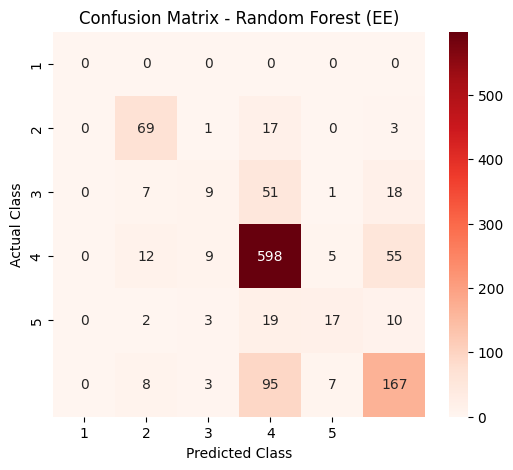

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix Random Forest
rf50_acc = rf_matrix.accuracy().getInfo()
rf50_kappa = rf_matrix.kappa().getInfo()
rf50_matrix = rf_matrix # Use rf_matrix from previous execution

print(f"Random Forest Accuracy: {rf50_acc:.4f}")
print(f"Random Forest Kappa: {rf50_kappa:.4f}")

cm_rf = np.array(rf50_matrix.getInfo())

class_names = [1,2,3,4,5]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Random Forest (EE)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()


In [24]:
# Random Forest (100 trees)
rf100 = ee.Classifier.smileRandomForest(
    numberOfTrees=100
).train(
    features=train,
    classProperty='class',
    inputProperties=features.bandNames()
)

rf_test = test.classify(rf100)

rf_matrix = rf_test.errorMatrix('class','classification')

print('RF Confusion Matrix:', rf_matrix.getInfo())
print('RF Overall Accuracy:', rf_matrix.accuracy().getInfo())
print('RF Kappa:', rf_matrix.kappa().getInfo())

producers = [i[0] for i in rf_matrix.producersAccuracy().getInfo()]
users = rf_matrix.consumersAccuracy().getInfo()[0]

print("Producer's Accuracy:", producers)
print("User's Accuracy:", users)

f1_scores = []

for p,u in zip(producers,users):
    if (p+u)==0:
        f1=0
    else:
        f1=2*(p*u)/(p+u)
    f1_scores.append(f1)

print("F1-score per class:",f1_scores)

RF Confusion Matrix: [[0, 0, 0, 0, 0, 0], [0, 71, 0, 18, 0, 1], [0, 6, 9, 52, 2, 17], [0, 11, 8, 603, 4, 53], [0, 2, 2, 20, 18, 9], [0, 7, 2, 94, 7, 170]]
RF Overall Accuracy: 0.7344013490725126
RF Kappa: 0.5271647095453016
Producer's Accuracy: [0, 0.7888888888888889, 0.10465116279069768, 0.8880706921944035, 0.35294117647058826, 0.6071428571428571]
User's Accuracy: [0, 0.7319587628865979, 0.42857142857142855, 0.7662007623888183, 0.5806451612903226, 0.68]
F1-score per class: [0, 0.7593582887700534, 0.16822429906542058, 0.8226466575716235, 0.4390243902439025, 0.6415094339622641]


In [25]:
# Gradient Tree Boost
gtb = ee.Classifier.smileGradientTreeBoost(
    numberOfTrees=100,
    shrinkage=0.1,
    maxNodes=20
).train(
    features=train,
    classProperty='class',
    inputProperties=features.bandNames()
)

gtb_test = test.classify(gtb)

gtb_matrix = gtb_test.errorMatrix('class','classification')

print('GTB Confusion Matrix:',gtb_matrix.getInfo())
print('GTB Overall Accuracy:',gtb_matrix.accuracy().getInfo())
print('GTB Kappa:',gtb_matrix.kappa().getInfo())

producers = [i[0] for i in gtb_matrix.producersAccuracy().getInfo()]
users = gtb_matrix.consumersAccuracy().getInfo()[0]

print("Producer's Accuracy:", producers)
print("User's Accuracy:", users)

f1_scores=[]

for p,u in zip(producers,users):
    if (p+u)==0:
        f1=0
    else:
        f1=2*(p*u)/(p+u)
    f1_scores.append(f1)

print("F1-score per class:",f1_scores)


GTB Confusion Matrix: [[0, 0, 0, 0, 0, 0], [0, 70, 1, 19, 0, 1], [0, 4, 9, 53, 2, 18], [0, 13, 3, 603, 6, 59], [0, 2, 1, 22, 14, 12], [0, 8, 2, 103, 6, 161]]
GTB Overall Accuracy: 0.7189597315436241
GTB Kappa: 0.49565079008226043
Producer's Accuracy: [0, 0.7692307692307693, 0.10465116279069768, 0.881578947368421, 0.27450980392156865, 0.575]
User's Accuracy: [0, 0.7216494845360825, 0.5625, 0.75375, 0.5, 0.6414342629482072]
F1-score per class: [0, 0.7446808510638298, 0.17647058823529413, 0.8126684636118598, 0.35443037974683544, 0.6064030131826741]


In [26]:
# Confusion Matrix Gradient Tree Boost
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_gtb = np.array(gtb_matrix.getInfo())

gtb_test = test.classify(gtb)

gtb_matrix = gtb_test.errorMatrix('class','classification')

print("GTB Confusion Matrix:")
print(gtb_matrix.getInfo())

GTB Confusion Matrix:
[[0, 0, 0, 0, 0, 0], [0, 70, 1, 19, 0, 1], [0, 4, 9, 53, 2, 18], [0, 13, 3, 603, 6, 59], [0, 2, 1, 22, 14, 12], [0, 8, 2, 103, 6, 161]]


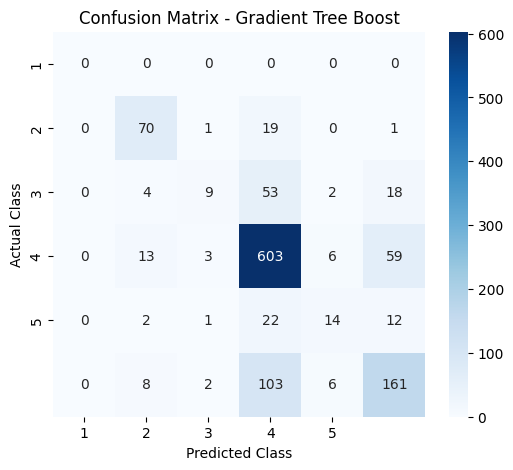

In [27]:
class_names = [1,2,3,4,5]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_gtb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Gradient Tree Boost")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [28]:
# Random Forest (50 trees)

rf50 = ee.Classifier.smileRandomForest(
    numberOfTrees=50
).train(
    features=train,
    classProperty='class',
    inputProperties=features.bandNames()
)

rf50_test = test.classify(rf50)
rf50_matrix = rf50_test.errorMatrix('class','classification')

rf50_acc = rf50_matrix.accuracy().getInfo()
rf50_kappa = rf50_matrix.kappa().getInfo()

rf50_producers = [i[0] for i in rf50_matrix.producersAccuracy().getInfo()]
rf50_users = rf50_matrix.consumersAccuracy().getInfo()[0]

rf50_f1 = []
for p,u in zip(rf50_producers,rf50_users):
    if (p+u)==0:
        f1=0
    else:
        f1=2*(p*u)/(p+u)
    rf50_f1.append(f1)

# Gradient Tree Boost

gtb_test = test.classify(gtb)
gtb_matrix = gtb_test.errorMatrix('class','classification')

gtb_acc = gtb_matrix.accuracy().getInfo()
gtb_kappa = gtb_matrix.kappa().getInfo()

gtb_producers = [i[0] for i in gtb_matrix.producersAccuracy().getInfo()]
gtb_users = gtb_matrix.consumersAccuracy().getInfo()[0]

gtb_f1 = []
for p,u in zip(gtb_producers,gtb_users):
    if (p+u)==0:
        f1=0
    else:
        f1=2*(p*u)/(p+u)
    gtb_f1.append(f1)

# Comparison

print("===== Model Comparison =====")

print("\nRandom Forest (50 Trees)")
print("Overall Accuracy:", rf50_acc)
print("Kappa:", rf50_kappa)
print("Producer's Accuracy:", rf50_producers)
print("User's Accuracy:", rf50_users)
print("F1-score:", rf50_f1)

print("\nGradient Tree Boost")
print("Overall Accuracy:", gtb_acc)
print("Kappa:", gtb_kappa)
print("Producer's Accuracy:", gtb_producers)
print("User's Accuracy:", gtb_users)
print("F1-score:", gtb_f1)

===== Model Comparison =====

Random Forest (50 Trees)
Overall Accuracy: 0.7290268456375839
Kappa: 0.5135284024431231
Producer's Accuracy: [0, 0.7582417582417582, 0.11627906976744186, 0.8903508771929824, 0.37254901960784315, 0.5785714285714286]
User's Accuracy: [0, 0.71875, 0.5263157894736842, 0.7574626865671642, 0.59375, 0.6721991701244814]
F1-score: [0, 0.7379679144385026, 0.1904761904761905, 0.8185483870967742, 0.4578313253012048, 0.6218809980806143]

Gradient Tree Boost
Overall Accuracy: 0.7189597315436241
Kappa: 0.49565079008226043
Producer's Accuracy: [0, 0.7692307692307693, 0.10465116279069768, 0.881578947368421, 0.27450980392156865, 0.575]
User's Accuracy: [0, 0.7216494845360825, 0.5625, 0.75375, 0.5, 0.6414342629482072]
F1-score: [0, 0.7446808510638298, 0.17647058823529413, 0.8126684636118598, 0.35443037974683544, 0.6064030131826741]


In [29]:
# Classification images
rf_classified = features.classify(rf50)
gtb_classified = features.classify(gtb)

# Map
Map_gtb = geemap.Map()
Map_gtb.centerObject(roi, 11)

# Random Forest layer
Map_gtb.addLayer(
    rf_classified,
    {'min':1,'max':5,'palette':['blue','cyan','yellow','green','red']},
    'Random Forest Classification'
)

# Gradient Tree Boost layer
Map_gtb.addLayer(
    gtb_classified,
    {'min':1,'max':5,'palette':['blue','cyan','yellow','green','red']},
    'Gradient Tree Boost Classification'
)

# Legend
legend_keys = ['Water','Wetland Vegetation','Agriculture','Forest','Urban']
legend_colors = [
    (0, 0, 255),    # Blue
    (0, 255, 255),  # Cyan
    (255, 255, 0),  # Yellow
    (0, 128, 0),    # Green
    (255, 0, 0)     # Red
]

Map_gtb.add_legend(
    title='Land Cover Classes',
    keys=legend_keys,
    colors=legend_colors
)

Map_gtb

Map(center=[14.62005629393108, 100.35163660829629], controls=(WidgetControl(options=['position', 'transparent_…

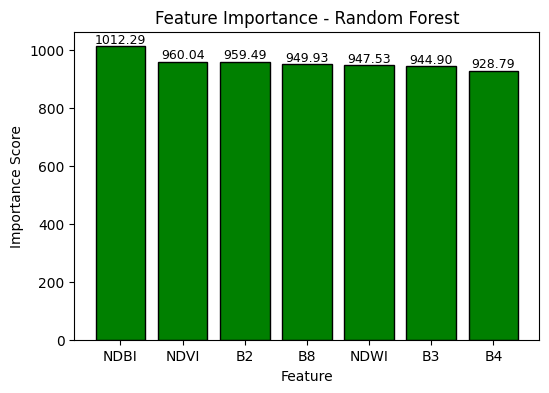

In [33]:
plt.figure(figsize=(6,4))

bars = plt.bar(df_importance["Feature"], df_importance["Importance"],
               color='green', edgecolor='black')

plt.title("Feature Importance - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance Score")

# ใส่ค่าบนแท่งกราฟ
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=9)

# Export รูป
plt.savefig("FeatureImportance_RF.png", dpi=300, bbox_inches='tight')

plt.show()

In [34]:
# Features without NDVI
features_no_ndvi = features.select(['B2','B3','B4','B8','NDWI','NDBI'])

# Train Random Forest
rf_no_ndvi = ee.Classifier.smileRandomForest(50).train(
    features=train,
    classProperty='class',
    inputProperties=features_no_ndvi.bandNames()
)

# Evaluate
rf_test_no_ndvi = test.classify(rf_no_ndvi)
rf_matrix_no_ndvi = rf_test_no_ndvi.errorMatrix('class','classification')

print("Accuracy without NDVI:", rf_matrix_no_ndvi.accuracy().getInfo())
print("Kappa without NDVI:", rf_matrix_no_ndvi.kappa().getInfo())

Accuracy without NDVI: 0.7298657718120806
Kappa without NDVI: 0.5180022076579863
